In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [12]:
def f1(x):
    return x**3 - 2*x - 5
    
def df1(x):
    return 3*x**2 - 2

In [13]:
# Problem 1(a)
def bisection(f, a, b, tol=1e-6):
    iterations = 0
    while (b-a)/2.0 > tol:
        c = (a+b)/2.0
        if f(c) == 0: # exact root is found
            break
        elif f(a)*f(c) < 0: # root is in the left half
            b = c
        else: # root is in the right half
            a = c
        iterations += 1

    return c, iterations

In [6]:
c, iterations = bisection(f1, 2, 3)
print(f"Root: {c}")
print(f"Iterations: {iterations}")

Root: 2.094552993774414
Iterations: 19


In [14]:
# Problem 1(b)
def g1(x):
    return(2*x + 5)**(1/3)
    
    pass
def fixed_point(g, x0, tol=1e-6, max_iter=100):
    x = x0
    iterations = 0
    for i in range(max_iter):
        x_new = g(x)
        iterations += 1
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x_new, iterations

root, iterations = fixed_point(g1, 2.0)
print(f"Root: {root}")
print(f"Iterations: {iterations}")

Root: 2.094551303182761
Iterations: 7


In [15]:
# Problem 1(c)
def newton(f, df, x0, tol=1e-6, max_iter=100):
    x = x0
    iterations = 0
    for _ in range(max_iter):
        x_new = x - f(x) / df(x) # Newtons update rule
        iterations += 1
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x_new, iterations

root, iterations = newton(f1, df1, 2.0)
print(f"Root: {root}")
print(f"Iterations: {iterations}")

Root: 2.0945514815423265
Iterations: 4


In [16]:
# Problem 1(d)
def secant(f, x0, x1, tol=1e-6, max_iter=100):
    iterations = 0
    for _ in range(max_iter):
        x2 = x1 - f(x1) *  (x1 - x0) / (f(x1) - f(x0))
        iterations += 1
        if abs(x2 - x1) < tol:
            break
        x0 = x1
        x1 = x2
    return x2, iterations

root, iterations = secant(f1, 2.0, 2.1)
print(f"Root: {root}")
print(f"Iterations: {iterations}")

Root: 2.0945514816982445
Iterations: 3


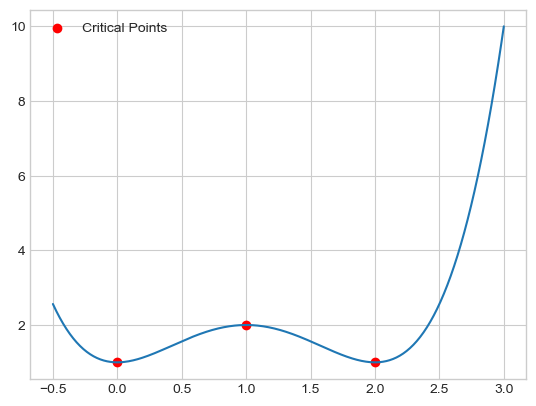

In [21]:
# Problem 2(a)
def f2(x):
    return x**4 - 4*x**3 + 4*x**2 + 1
    
x_vals = np.linspace(-0.5, 3, 400)
y_vals = f2(x_vals)

plt.plot(x_vals, y_vals)

critical_points = [0, 1, 2]
Y_critical_points = [f2(i)  for i in critical_points]

plt.scatter(critical_points, Y_critical_points, color='red', label = "Critical Points")
plt.legend()
plt.show()

In [25]:
# Problem 2(b)
def ddf2(x):
    return 12*x**2 - 24*x + 8
    
for i in critical_points:
    f_double_prime = ddf2(i)

    if f_double_prime > 0:
        classification = "Local Minimizer"
    elif f_double_prime < 0:
        classification = "Local Maximizer"
    else:
      classification = "Inconclusive"

    print(i, classification)  

0 Local Minimizer
1 Local Maximizer
2 Local Minimizer


Iterates: [1.8, 2.1130434782608694, 2.0151754584477466, 2.0003336323133825, 2.000000166835905, 2.000000000000041]


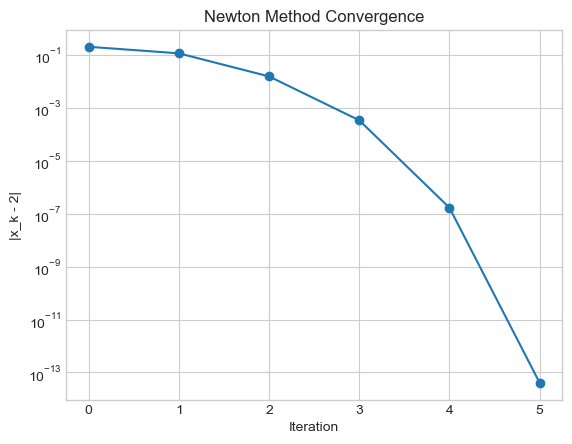

In [28]:
# Problem 2(c)
def df2(x):
    return 4*x**3 - 12*x**2 + 8*x

x = 1.8
tol = 1e-6
iterates = [x]

while True:
    x_new = x - df2(x) / ddf2(x)
    iterates.append(x_new)

    if abs(x_new - x) < tol:
        break

    x = x_new

print("Iterates:", iterates)

errors = [abs(x - 2) for x in iterates]
k = range(len(iterates))

plt.plot(k, errors, marker='o')
plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("|x_k - 2|")
plt.title("Newton Method Convergence")
plt.show()